In [54]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [47]:
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jul07/"
Bias_Null_Dir = Bias_Save_Dir + "CTRL/RandGeneBias_Spec/"

### ASD/SCZ

Loaded 10000 control DataFrames
Processing 461 cell types with 10000 permutations...


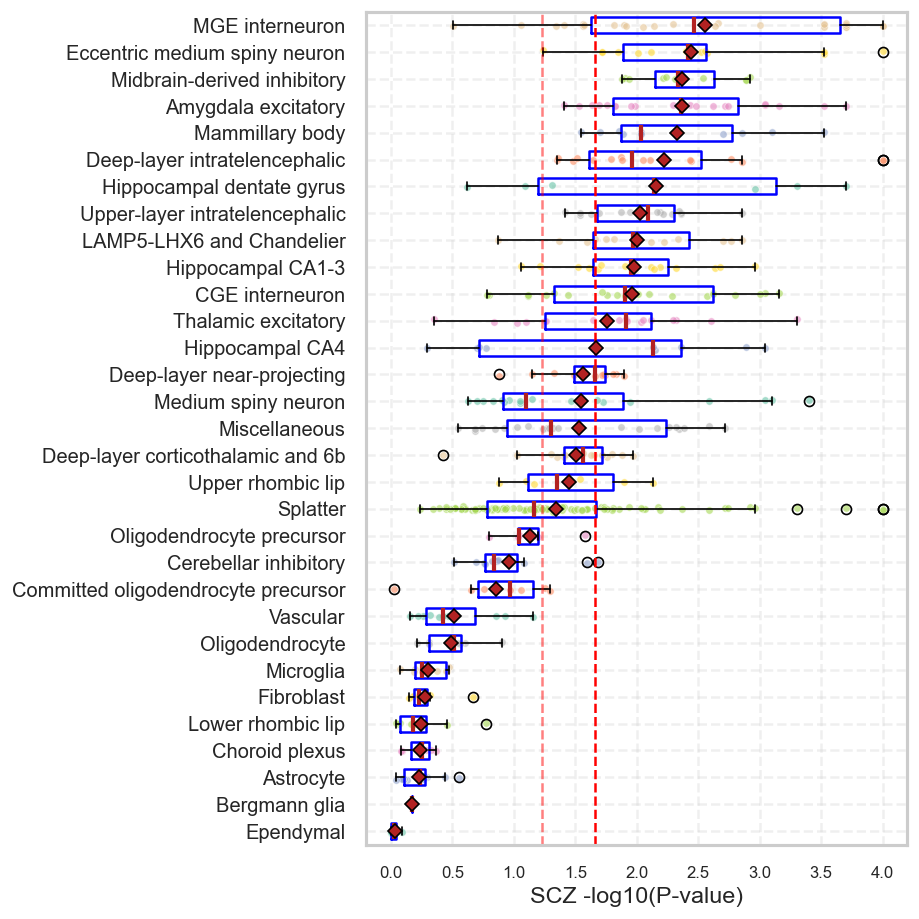

In [48]:
RandG_SCZ_top61_DIR = "{}/RandGene_SCZ.top61".format(Bias_Null_Dir)
RandG_SCZ_top61_DFs = LoadNullDF(RandG_SCZ_top61_DIR)

SCZ_Bias_top61 = pd.read_csv("{}/HCT.SCZ61.csv".format(Bias_Save_Dir), index_col=0)
SCZ_Bias_top61_P_randG = AddPvalue_optimized(SCZ_Bias_top61, RandG_SCZ_top61_DFs)
SCZ_Bias_top61_P_randG.to_csv("{}/HCT.SCZ61.addP.csv".format(Bias_Save_Dir))
SuperClusterBias_BoxPlot(SCZ_Bias_top61_P_randG, "SCZ", NeuroOnly=False, sortby="mean", EffectCol="-logP")

In [49]:
VIP_Anno = pd.read_csv("VIP_Anno.csv", index_col=0)
common_indices = SCZ_Bias_top61_P_randG.index.intersection(VIP_Anno.index)
SCZ_Bias_top61_P_randG_sub = SCZ_Bias_top61_P_randG.loc[common_indices].copy()
SCZ_Bias_top61_P_randG_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

In [50]:
SCZ_Bias_top61_P_randG_sub.head(2)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,P-value,Z-score,EFFECT_adj,q-value,-logP,VIP
281,0.226198,24,NEUR,CGE interneuron,INT-VIP,GABA,"Cerebral cortex: 70.5%, Amygdala: 13.0%, Hippo...","Human Pir: 5.7%, Human MEC: 4.6%, Human M1C: 4.5%",2234.0,CCK CHGA CHGB CRH IGF NAMPT NUCB PNOC SCG UBL ...,0.0007,3.309860,0.227193,0.011524,3.154945,4.373322
278,0.219342,30,NEUR,CGE interneuron,NaN,GABA VGLUT3,"Cerebral cortex: 78.0%, Amygdala: 10.4%, Hippo...","Human MEC: 5.9%, Human LEC: 4.8%, Human M1C: 4.7%",7177.0,CCK CHGA CHGB CRH IGF NAMPT NPW NUCB NXPH PNOC...,0.0009,3.073818,0.219908,0.011853,3.045801,0.081232


/tmp/ipykernel_533086/1417339535.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


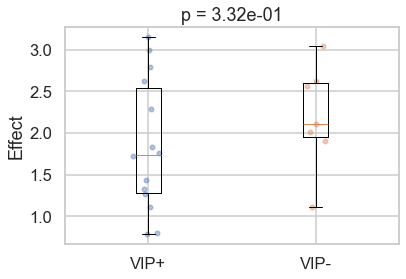

In [51]:
VIP_pos = SCZ_Bias_top61_P_randG_sub[SCZ_Bias_top61_P_randG_sub["VIP"] >= 1]
VIP_neg = SCZ_Bias_top61_P_randG_sub[SCZ_Bias_top61_P_randG_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
EFFECT = "-logP"
data = [VIP_pos[EFFECT], VIP_neg[EFFECT]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(VIP_pos[EFFECT], 
                                    VIP_neg[EFFECT])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([VIP_pos[EFFECT], VIP_neg[EFFECT]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()


In [52]:
N_VIP_Sig = VIP_pos[VIP_pos["q-value"]< 0.05].shape[0]
N_nonVIP_Sig = VIP_neg[VIP_neg["q-value"]< 0.05].shape[0]
N_total_VIP = VIP_pos.shape[0]
N_total_nonVIP = VIP_neg.shape[0]
print(f"VIP+: {N_VIP_Sig}, VIP-: {N_nonVIP_Sig}")
print(f"VIP+: {N_VIP_Sig/N_total_VIP}, VIP-: {N_nonVIP_Sig/N_total_nonVIP}")

VIP+: 8, VIP-: 6
VIP+: 0.5714285714285714, VIP-: 0.8571428571428571


In [53]:
# Test if N_VIP_Sig is significantly more than expected by chance using a binomial test
from scipy.stats import binom_test

# Assume the expected proportion of significant genes is the same as in VIP- group
expected_prop = N_nonVIP_Sig / N_total_nonVIP if N_total_nonVIP > 0 else 0

# Perform one-sided binomial test: is N_VIP_Sig greater than expected under null?
p_binom = binom_test(N_VIP_Sig, N_total_VIP, expected_prop, alternative='greater')

print(f"Binomial test p-value (VIP+ > expected): {p_binom:.3g}")
N_VIP_Sig, N_nonVIP_Sig, N_total_VIP, N_total_nonVIP

Binomial test p-value (VIP+ > expected): 0.998


/tmp/ipykernel_533086/1882308637.py:8: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  p_binom = binom_test(N_VIP_Sig, N_total_VIP, expected_prop, alternative='greater')


(8, 6, 14, 7)

In [55]:
SuperCluster_SCZ_df = test_all_superclusters_vectorized(ALL_CTs, Anno, SCZ_Bias_top61_P_randG, RandG_SCZ_top61_DFs)
SuperCluster_SCZ_df.to_csv("{}/SuperCluster_SCZ.Pvalue.csv".format(Bias_Save_Dir))
SuperCluster_SCZ_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.179873,3.331818,0.000800,0.012399
12,MGE interneuron,0.182278,3.299993,0.000800,0.012399
16,Miscellaneous,0.133305,3.111446,0.002200,0.016532
13,Mammillary body,0.185615,2.973176,0.003200,0.016532
4,Deep-layer intratelencephalic,0.175328,3.050304,0.002800,0.016532
6,Eccentric medium spiny neuron,0.180280,3.104809,0.002400,0.016532
20,Upper-layer intratelencephalic,0.167693,2.659432,0.007999,0.022989
10,LAMP5-LHX6 and Chandelier,0.157038,2.611414,0.008899,0.022989
9,Hippocampal dentate gyrus,0.177972,2.644110,0.007599,0.022989
15,Midbrain-derived inhibitory,0.188513,2.814266,0.005299,0.022989


In [56]:
RandG_ASD_HIQ_top61_DIR = "{}/RandGene_ASD_HIQ.top61/".format(Bias_Null_Dir)
RandG_ASD_HIQ_top61_DFs = LoadNullDF(RandG_ASD_HIQ_top61_DIR)
RandG_ASD_LIQ_top61_DIR = "{}/RandGene_ASD_LIQ.top61/".format(Bias_Null_Dir)
RandG_ASD_LIQ_top61_DFs = LoadNullDF(RandG_ASD_LIQ_top61_DIR)

Loaded 10000 control DataFrames
Loaded 10000 control DataFrames


In [57]:
ASD_HIQ_Bias_top61 = pd.read_csv("{}/HCT.ASD61.HIQ.csv".format(Bias_Save_Dir), index_col=0)
ASD_HIQ_Bias_top61_P_randG = AddPvalue_optimized(ASD_HIQ_Bias_top61, RandG_ASD_HIQ_top61_DFs)
ASD_LIQ_Bias_top61 = pd.read_csv("{}/HCT.ASD61.LIQ.csv".format(Bias_Save_Dir), index_col=0)
ASD_LIQ_Bias_top61_P_randG = AddPvalue_optimized(ASD_LIQ_Bias_top61, RandG_ASD_LIQ_top61_DFs)

ASD_HIQ_Bias_top61_P_randG.to_csv("{}/HCT.ASD61.HIQ.P_randG.csv".format(Bias_Save_Dir), index=False)
ASD_LIQ_Bias_top61_P_randG.to_csv("{}/HCT.ASD61.LIQ.P_randG.csv".format(Bias_Save_Dir), index=False)

Processing 461 cell types with 10000 permutations...
Processing 461 cell types with 10000 permutations...


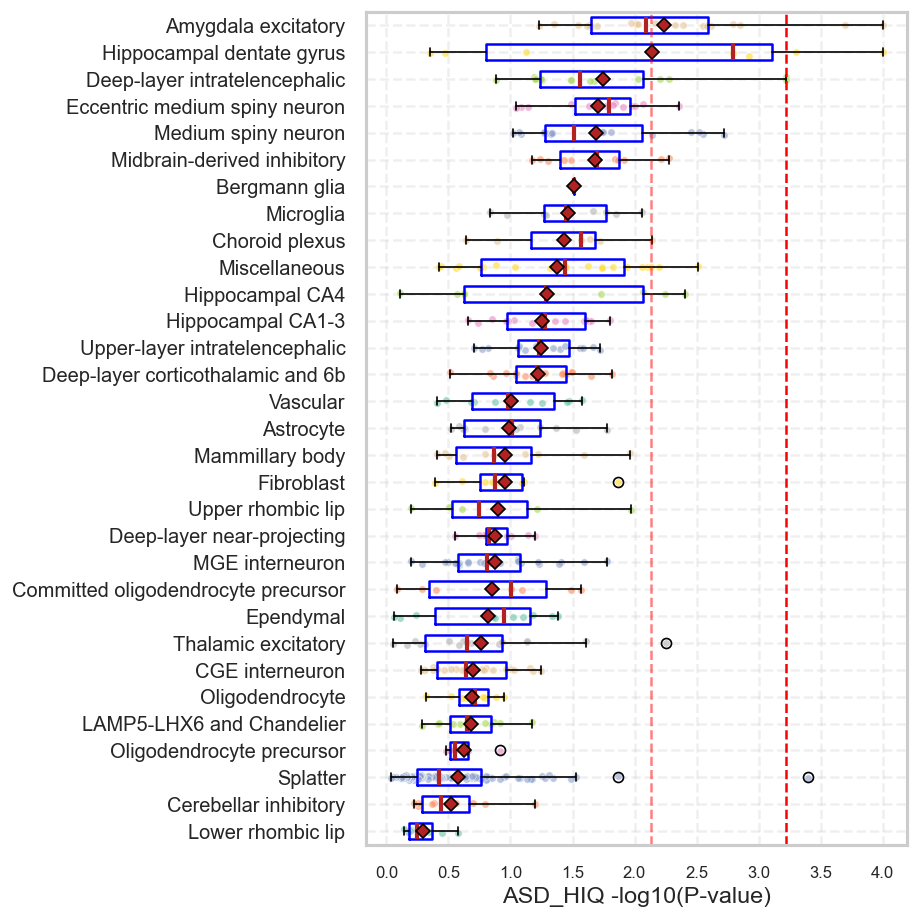

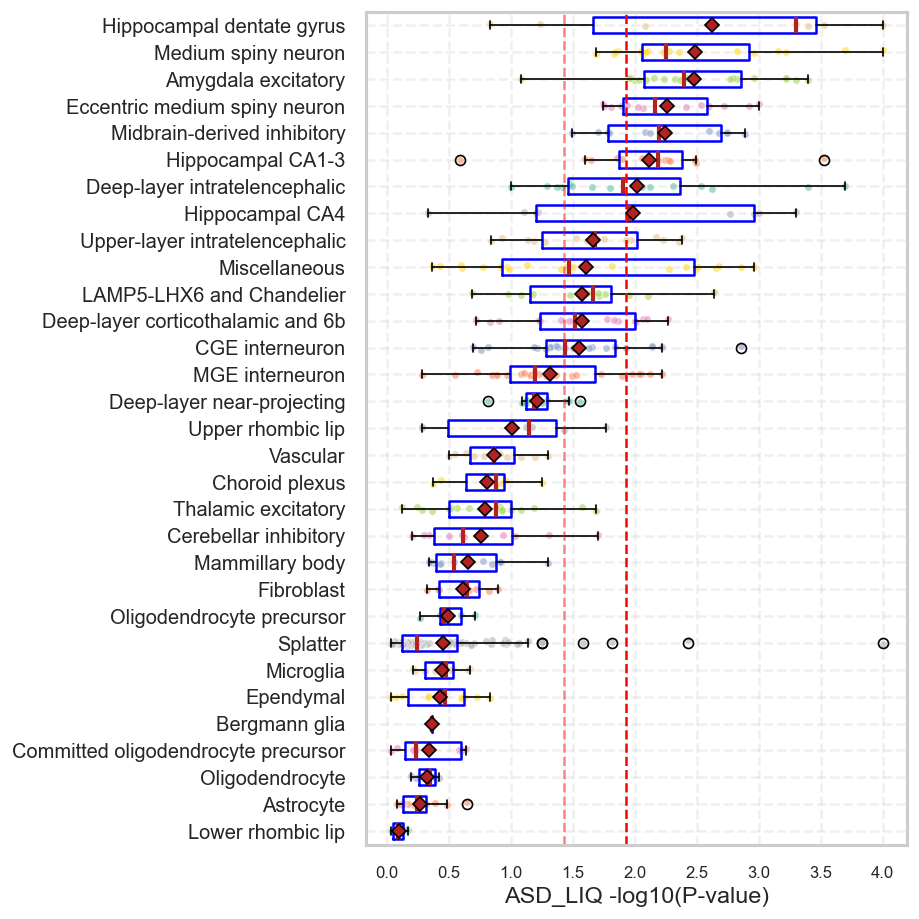

In [58]:
ASD_HIQ_Bias_top61_P_randG["-logP"] = -np.log10(ASD_HIQ_Bias_top61_P_randG["P-value"])
SuperClusterBias_BoxPlot(ASD_HIQ_Bias_top61_P_randG, "ASD_HIQ", NeuroOnly=False, sortby="mean", EffectCol="-logP")
ASD_LIQ_Bias_top61_P_randG["-logP"] = -np.log10(ASD_LIQ_Bias_top61_P_randG["P-value"])
SuperClusterBias_BoxPlot(ASD_LIQ_Bias_top61_P_randG, "ASD_LIQ", NeuroOnly=False, sortby="mean", EffectCol="-logP")

In [59]:
SuperCluster_ASD_HIQ_df = test_all_superclusters_vectorized(ALL_CTs, Anno, ASD_HIQ_Bias_top61_P_randG, RandG_ASD_HIQ_top61_DFs)
SuperCluster_ASD_LIQ_df = test_all_superclusters(ALL_CTs, Anno, ASD_LIQ_Bias_top61_P_randG, RandG_ASD_LIQ_top61_DFs)
#SuperCluster_ASD_HIQ_df

In [60]:
SuperCluster_ASD_HIQ_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.219351,3.187711,0.001100,0.034097
16,Miscellaneous,0.161872,2.989717,0.003800,0.058894
14,Medium spiny neuron,0.187963,2.328193,0.018898,0.097640
9,Hippocampal dentate gyrus,0.204667,2.394263,0.015698,0.097640
4,Deep-layer intratelencephalic,0.182476,2.507100,0.012699,0.097640
6,Eccentric medium spiny neuron,0.174361,2.380632,0.016498,0.097640
15,Midbrain-derived inhibitory,0.188657,2.199384,0.026997,0.119559
7,Hippocampal CA1-3,0.140497,1.856601,0.063594,0.179218
27,Microglia,0.241670,1.935810,0.053995,0.179218
23,Choroid plexus,0.224531,1.872700,0.059494,0.179218


In [61]:
SuperCluster_ASD_LIQ_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.240167,3.626626,0.000600,0.006199
16,Miscellaneous,0.169366,3.251917,0.000200,0.006199
14,Medium spiny neuron,0.250052,3.223015,0.000600,0.006199
9,Hippocampal dentate gyrus,0.267300,3.219757,0.001100,0.008524
6,Eccentric medium spiny neuron,0.212084,3.006645,0.001500,0.009299
4,Deep-layer intratelencephalic,0.198052,2.786229,0.002900,0.012842
7,Hippocampal CA1-3,0.217782,2.932735,0.002600,0.012842
15,Midbrain-derived inhibitory,0.228311,2.755694,0.003600,0.013949
8,Hippocampal CA4,0.197623,2.484591,0.007999,0.027553
1,CGE interneuron,0.160711,2.214731,0.010599,0.032857


In [62]:
#RandG_DDD_DIR = "{}/RandGene_DDD.top61_Jun11/".format(Bias_Null_Dir)
RandG_DDD_top61_DIR = "{}/RandGene_DDD.top61/".format(Bias_Null_Dir)
RandG_DDD_top61_DFs = LoadNullDF(RandG_DDD_top61_DIR)

Loaded 10000 control DataFrames


Processing 461 cell types with 10000 permutations...


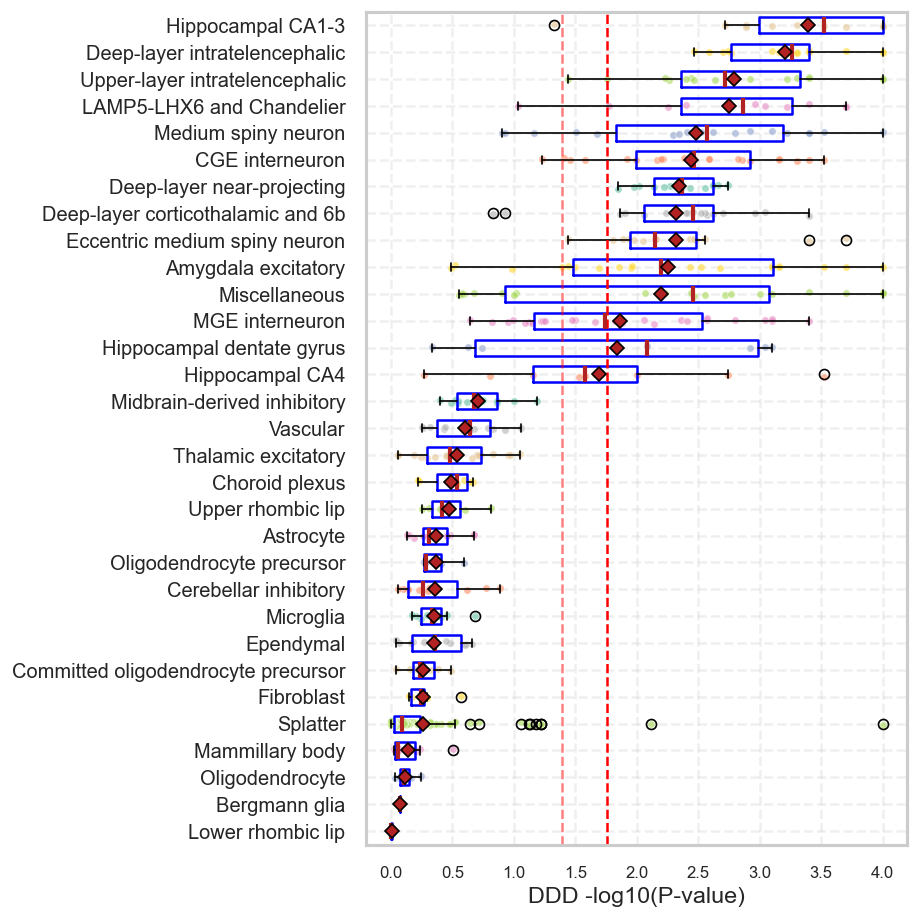

In [63]:
DDD_Bias = pd.read_csv("{}/HCT.DDDHC.Spec.top61.csv".format(Bias_Save_Dir), index_col=0)
DDD_Bias_P_randG = AddPvalue_optimized(DDD_Bias, RandG_DDD_top61_DFs)
DDD_Bias_P_randG.to_csv("{}/HCT.DDD.top61.addP.csv".format(Bias_Save_Dir))
#DDD_Bias_P_randG.head(20)
SuperClusterBias_BoxPlot(DDD_Bias_P_randG, "DDD", NeuroOnly=False, sortby="mean", EffectCol="-logP")

In [17]:
SuperCluster_DDD_df = test_all_superclusters(ALL_CTs, Anno, DDD_Bias_P_randG, RandG_DDD_top61_DFs)
SuperCluster_DDD_df 

,Supercluster,Observed_Effect,Z_score,P_value,FDR
20,Upper-layer intratelencephalic,0.221808,3.345208,0.000100,0.000775
4,Deep-layer intratelencephalic,0.250715,4.095779,0.000100,0.000775
7,Hippocampal CA1-3,0.280796,4.391987,0.000100,0.000775
16,Miscellaneous,0.180908,4.004970,0.000100,0.000775
10,LAMP5-LHX6 and Chandelier,0.214226,3.273268,0.000300,0.001860
1,CGE interneuron,0.200746,3.205684,0.000400,0.002066
0,Amygdala excitatory,0.178087,3.106938,0.000700,0.003100
14,Medium spiny neuron,0.210267,3.114994,0.000900,0.003487
6,Eccentric medium spiny neuron,0.186441,3.002617,0.001200,0.004133
3,Deep-layer corticothalamic and 6b,0.188797,3.043540,0.001500,0.004650


In [18]:
RandG_22q_DIR = "{}/RandGene_22q_del/".format(Bias_Null_Dir)
RandG_22q_top61_DFs = LoadNullDF(RandG_22q_DIR)

Loaded 10000 control DataFrames


Processing 461 cell types with 10000 permutations...


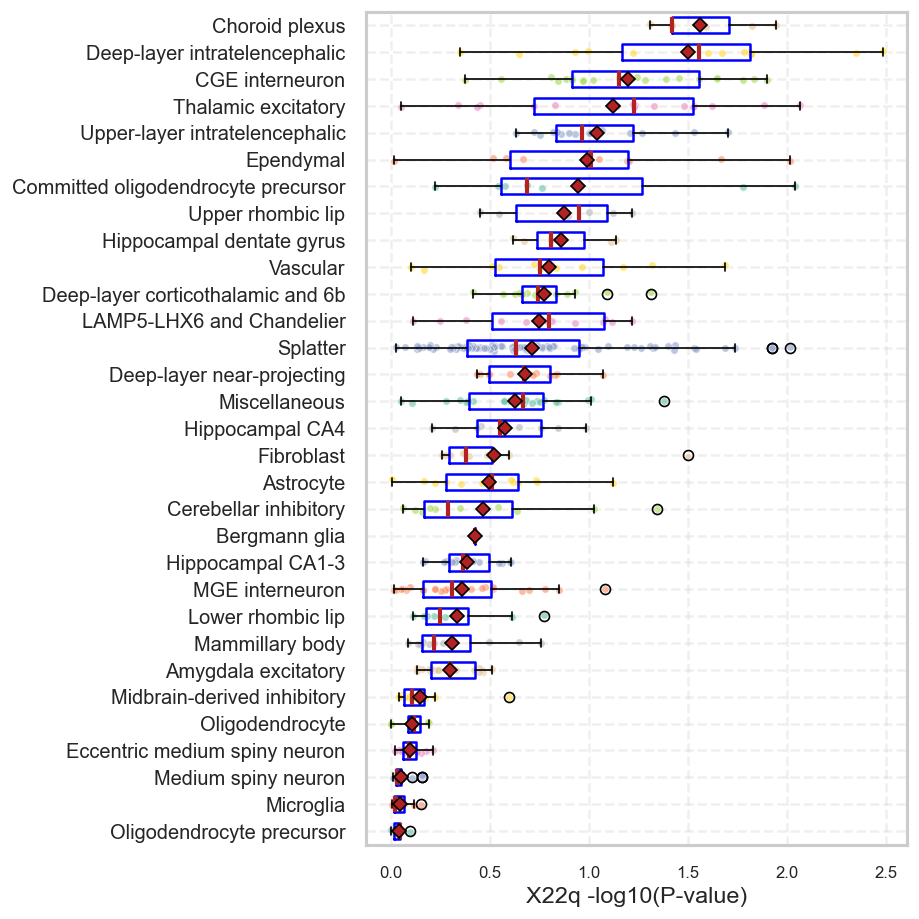

In [64]:
X22q_Bias = pd.read_csv("{}/HCT.X22q.csv".format(Bias_Save_Dir), index_col=0)
X22q_Bias_P_randG = AddPvalue_optimized(X22q_Bias, RandG_22q_top61_DFs)
X22q_Bias_P_randG.to_csv("{}/HCT.X22q.addP.csv".format(Bias_Save_Dir))
#X22q_Bias_P_randG.head(20)
SuperClusterBias_BoxPlot(X22q_Bias_P_randG, "X22q", NeuroOnly=False, sortby="mean", EffectCol="-logP")

In [65]:
SuperCluster_22q_df = test_all_superclusters_vectorized(ALL_CTs, Anno, X22q_Bias_P_randG, RandG_22q_top61_DFs)
SuperCluster_22q_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
30,Vascular,0.089858,1.037372,0.299770,0.546639
16,Miscellaneous,0.047906,1.054273,0.289971,0.546639
29,Oligodendrocyte precursor,-0.138670,-1.744957,0.081292,0.546639
14,Medium spiny neuron,-0.105661,-1.534973,0.124088,0.546639
20,Upper-layer intratelencephalic,0.097237,1.465979,0.146085,0.546639
23,Choroid plexus,0.201152,2.044950,0.040196,0.546639
24,Committed oligodendrocyte precursor,0.091416,1.355945,0.170483,0.546639
18,Thalamic excitatory,0.102240,1.600602,0.109289,0.546639
9,Hippocampal dentate gyrus,0.084135,1.201021,0.227077,0.546639
27,Microglia,-0.160535,-1.544860,0.122188,0.546639


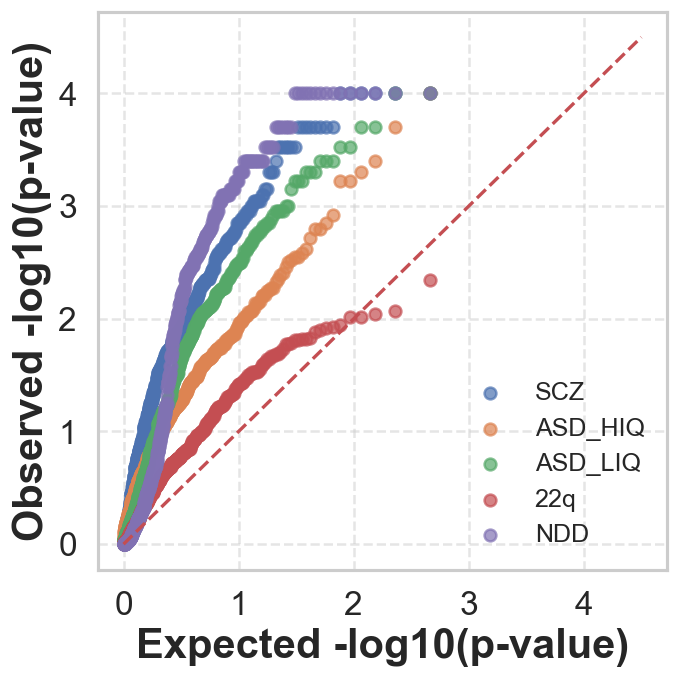

In [66]:
PlotQQ([SCZ_Bias_top61_P_randG, ASD_HIQ_Bias_top61_P_randG, ASD_LIQ_Bias_top61_P_randG, X22q_Bias_P_randG, DDD_Bias_P_randG], 
[ "SCZ", "ASD_HIQ", "ASD_LIQ", "22q", "NDD"])

In [67]:
RandG_VNR_DIR = "{}/RandGene_UKBB_VNR.top61/".format(Bias_Null_Dir)
RandG_VNR_top61_DFs = LoadNullDF(RandG_VNR_DIR)
RandG_EDU_DIR = "{}/RandGene_UKBB_EDU.top61/".format(Bias_Null_Dir)
RandG_EDU_top61_DFs = LoadNullDF(RandG_EDU_DIR)

Loaded 10000 control DataFrames
Loaded 10000 control DataFrames


In [69]:
UKBB_VNR_Neg_Bias = pd.read_csv("{}/HCT.VNR.Neg.top61.csv".format(Bias_Save_Dir), index_col=0)
UKBB_VNR_Neg_Bias_P_randG = AddPvalue_optimized(UKBB_VNR_Neg_Bias, RandG_VNR_top61_DFs)

UKBB_EDU_Neg_Bias = pd.read_csv("{}/HCT.EDU.Neg.top61.csv".format(Bias_Save_Dir), index_col=0)
UKBB_EDU_Neg_Bias_P_randG = AddPvalue_optimized(UKBB_EDU_Neg_Bias, RandG_EDU_top61_DFs)


Processing 461 cell types with 10000 permutations...
Processing 461 cell types with 10000 permutations...


In [68]:
UKBB_VNR_Pos_Bias = pd.read_csv("{}/HCT.VNR.Pos.top61.csv".format(Bias_Save_Dir), index_col=0)
UKBB_VNR_Pos_Bias_P_randG = AddPvalue_optimized(UKBB_VNR_Pos_Bias, RandG_VNR_top61_DFs)

UKBB_EDU_Pos_Bias = pd.read_csv("{}/HCT.EDU.Pos.top61.csv".format(Bias_Save_Dir), index_col=0)
UKBB_EDU_Pos_Bias_P_randG = AddPvalue_optimized(UKBB_EDU_Pos_Bias, RandG_EDU_top61_DFs)

Processing 461 cell types with 10000 permutations...
Processing 461 cell types with 10000 permutations...


In [70]:
UKBB_VNR_Neg_Bias_P_randG.to_csv(Bias_Save_Dir + "UKBB_VNR_Neg_Bias_addP.csv")
UKBB_EDU_Neg_Bias_P_randG.to_csv(Bias_Save_Dir + "UKBB_EDU_Neg_Bias_addP.csv")

UKBB_VNR_Pos_Bias_P_randG.to_csv(Bias_Save_Dir + "UKBB_VNR_Pos_Bias_addP.csv")
UKBB_EDU_Pos_Bias_P_randG.to_csv(Bias_Save_Dir + "UKBB_EDU_Pos_Bias_addP.csv")

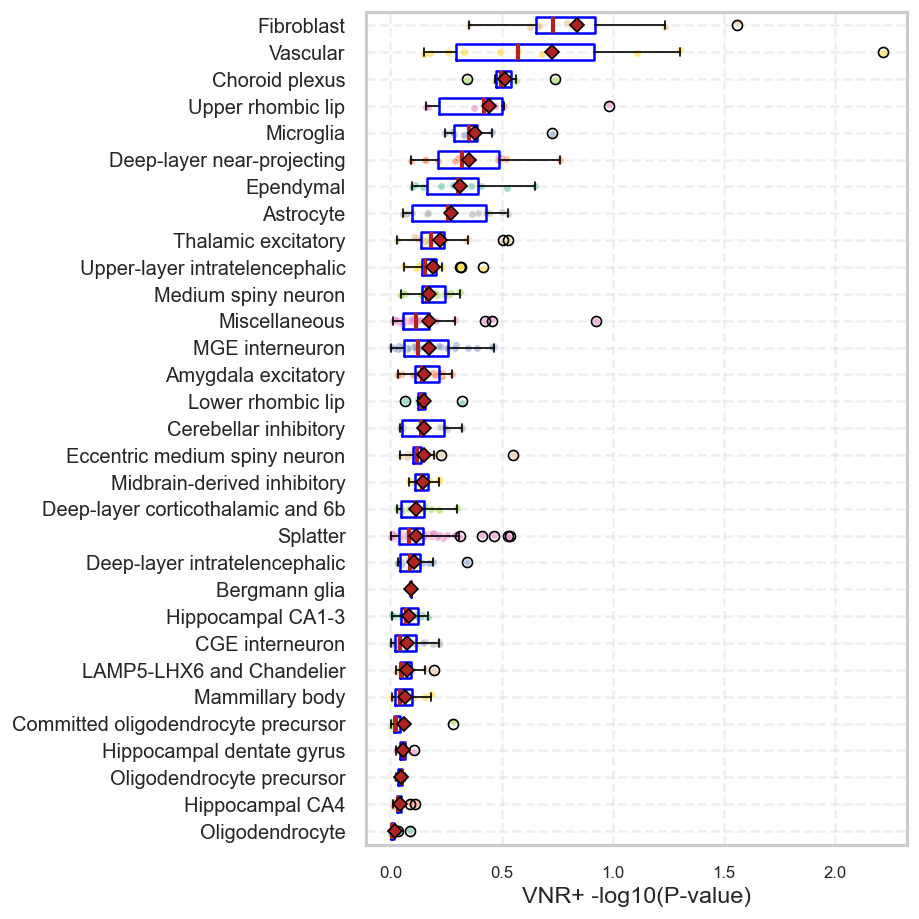

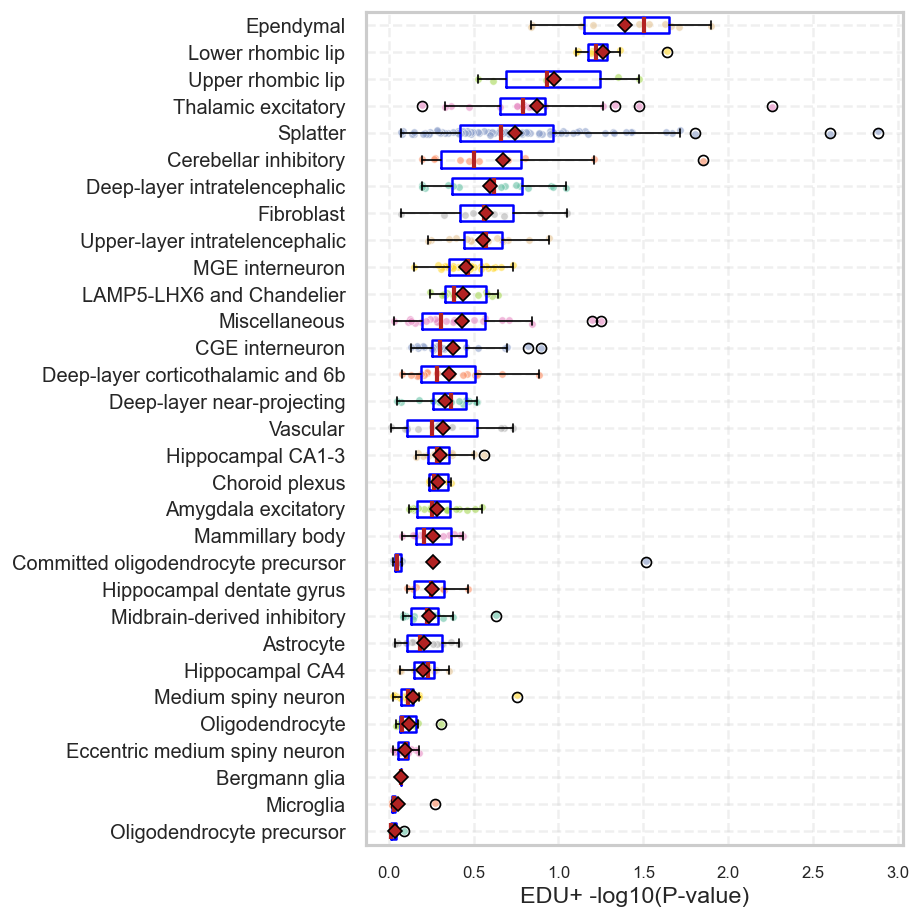

In [71]:
SuperClusterBias_BoxPlot(UKBB_VNR_Pos_Bias_P_randG, "VNR+", NeuroOnly=False, sortby="mean", EffectCol="-logP")
SuperClusterBias_BoxPlot(UKBB_EDU_Pos_Bias_P_randG, "EDU+", NeuroOnly=False, sortby="mean", EffectCol="-logP")

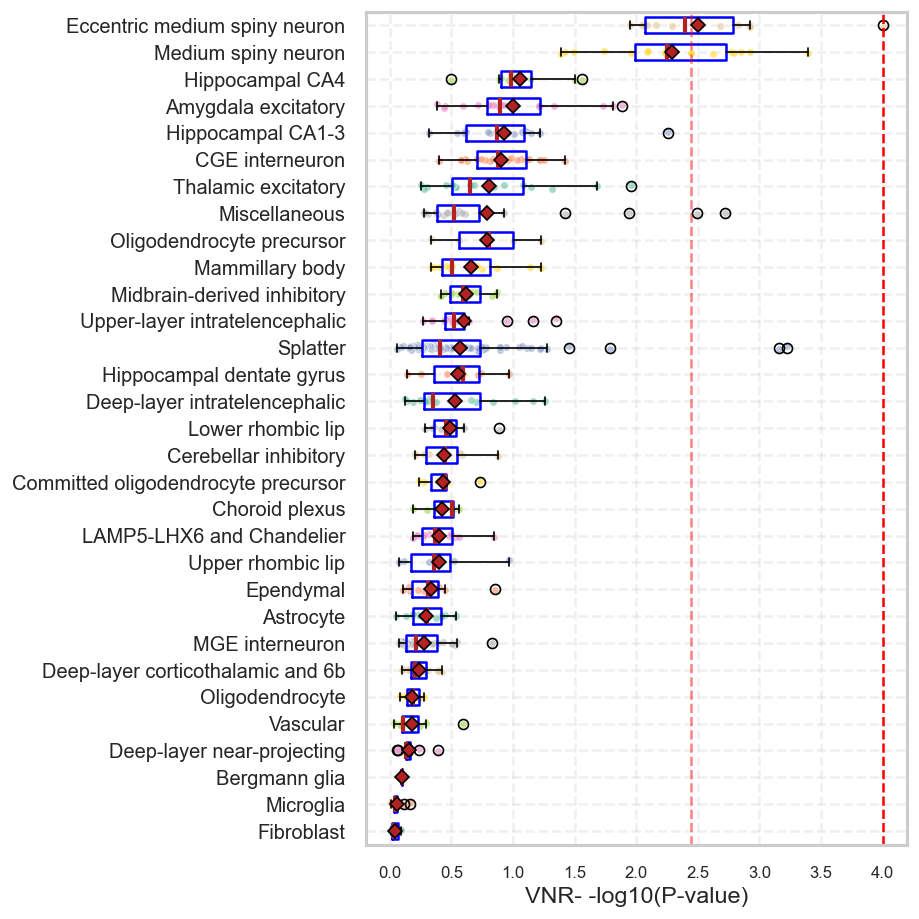

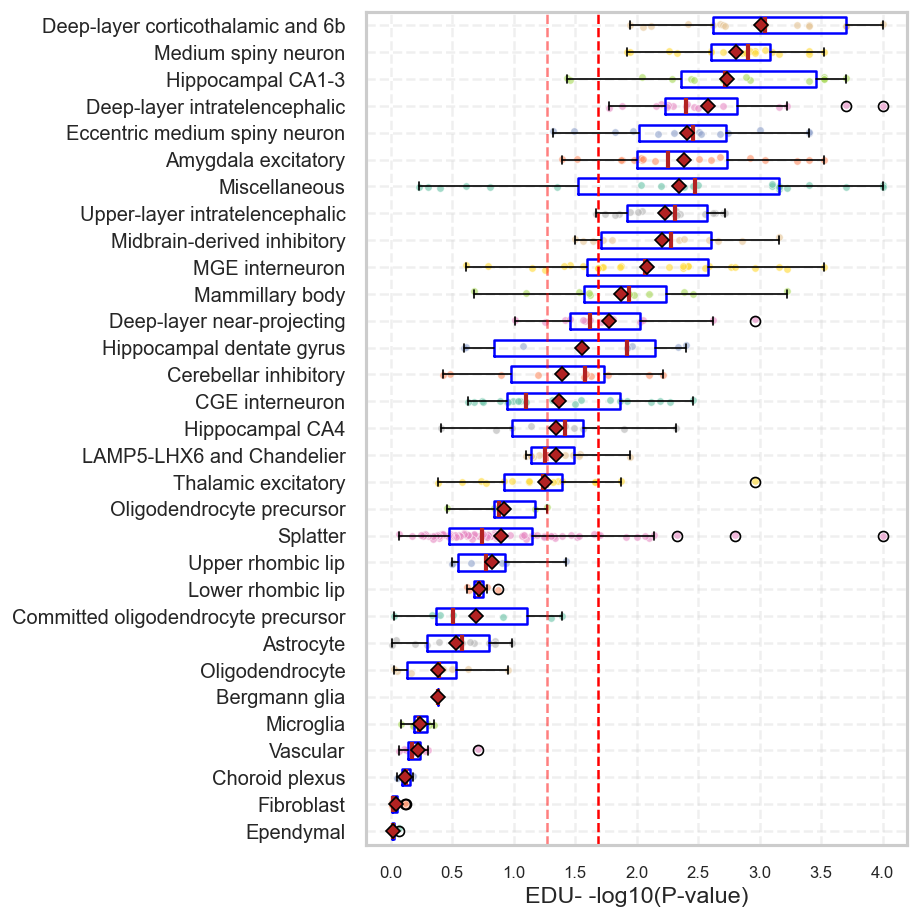

In [72]:
SuperClusterBias_BoxPlot(UKBB_VNR_Neg_Bias_P_randG, "VNR-", NeuroOnly=False, sortby="mean", EffectCol="-logP")
SuperClusterBias_BoxPlot(UKBB_EDU_Neg_Bias_P_randG, "EDU-", NeuroOnly=False, sortby="mean", EffectCol="-logP")